In [3]:
# Cell 1 — Load the offline slot-classification deployment package

from pathlib import Path
from PIL import Image
import json
import re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

PROJECT_ROOT = Path("/homes/mxqasim/Chocolathon")
DEPLOYMENT_DIR = PROJECT_ROOT / "data/experiments/synthetic_slot_embeddings_v1/deployment"
SYNTHETIC_MANIFEST = PROJECT_ROOT / "data/synthetic_slots/v1/dataset/synthetic_slot_manifest.csv"
INTEGRATION_DIR = PROJECT_ROOT / "data/experiments/real_box_inference_v1/synthetic_integration"
BOX_IMAGE_DIR = INTEGRATION_DIR / "boxes"
OUTPUT_DIR = INTEGRATION_DIR / "outputs"

BOX_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(DEPLOYMENT_DIR / "deployment_config.json", encoding="utf-8") as file:
    deployment_config = json.load(file)

prototype_cache = np.load(DEPLOYMENT_DIR / "slot_class_prototypes.npz", allow_pickle=False)
class_prototypes = prototype_cache["prototypes"]
class_ids = prototype_cache["class_ids"].astype(str)
class_catalog = pd.read_csv(DEPLOYMENT_DIR / "class_catalog.csv")
class_name_lookup = class_catalog.set_index("flavor_id")["flavor_name"].to_dict()

model = efficientnet_b0(weights=None)
model.classifier = torch.nn.Identity()
model.load_state_dict(torch.load(DEPLOYMENT_DIR / "efficientnet_b0_feature_extractor.pt", map_location="cpu", weights_only=True))
model.eval()

transform = EfficientNet_B0_Weights.IMAGENET1K_V1.transforms()
synthetic_manifest = pd.read_csv(SYNTHETIC_MANIFEST)
synthetic_manifest["image_path"] = synthetic_manifest["relative_path"].map(lambda path: str(PROJECT_ROOT / Path(path)))

print("Deployment classes:", len(class_ids))
print("Prototypes:", class_prototypes.shape)
print("Synthetic samples:", len(synthetic_manifest))
print("Confidence threshold:", deployment_config["provisional_margin_threshold"])
print("PASS: offline deployment package loaded")

Deployment classes: 34
Prototypes: (34, 1280)
Synthetic samples: 3718
Confidence threshold: 0.005
PASS: offline deployment package loaded


/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [4]:
# Cell 2 — Assemble logical full-box integration cases from validation slots

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
validation_rows = synthetic_manifest[synthetic_manifest["split"].eq("validation")].copy()
empty_rows = validation_rows[validation_rows["label_type"].eq("empty")].copy()
occupied_rows = validation_rows[validation_rows["label_type"].eq("occupied")].copy()

def parse_position(filename):
    match = re.search(r"_r(\d+)_c(\d+)", filename)
    if not match:
        raise ValueError(f"Cannot parse row and column from {filename}")
    return int(match.group(1)), int(match.group(2))

integration_rows = []

for source_file, source_slots in empty_rows.groupby("empty_source_file"):
    source_slots = source_slots.copy()
    source_slots[["row", "column"]] = source_slots["empty_slot_file"].apply(lambda name: pd.Series(parse_position(name)))
    max_row, max_column = source_slots["row"].max(), source_slots["column"].max()
    canvas = Image.new("RGB", (max_column * 224, max_row * 224), "black")

    for _, empty_row in source_slots.sort_values(["row", "column"]).iterrows():
        candidates = occupied_rows[occupied_rows["empty_slot_file"].eq(empty_row["empty_slot_file"])]
        use_occupied = rng.random() < 0.75 and len(candidates) > 0
        selected = candidates.iloc[rng.integers(len(candidates))] if use_occupied else empty_row

        with Image.open(selected["image_path"]) as image:
            slot_image = image.convert("RGB")
            canvas.paste(slot_image, ((empty_row["column"] - 1) * 224, (empty_row["row"] - 1) * 224))

        integration_rows.append({
            "test_box_id": Path(source_file).stem,
            "empty_source_file": source_file,
            "box_size": int(empty_row["box_size"]),
            "row": int(empty_row["row"]),
            "column": int(empty_row["column"]),
            "sample_id": selected["sample_id"],
            "image_path": selected["image_path"],
            "true_flavor_id": selected["flavor_id"],
            "true_flavor_name": selected["flavor_name"],
            "label_type": selected["label_type"],
        })

    canvas.save(BOX_IMAGE_DIR / f"{Path(source_file).stem}_synthetic_box.jpg", quality=95)

integration_manifest = pd.DataFrame(integration_rows)
INTEGRATION_MANIFEST = OUTPUT_DIR / "synthetic_box_slot_manifest.csv"
integration_manifest.to_csv(INTEGRATION_MANIFEST, index=False)

print("Synthetic test boxes:", integration_manifest["test_box_id"].nunique())
print("Total slots:", len(integration_manifest))
print("Occupied:", integration_manifest["label_type"].eq("occupied").sum())
print("Empty:", integration_manifest["label_type"].eq("empty").sum())
print("Box images:", BOX_IMAGE_DIR)
display(integration_manifest.groupby(["test_box_id", "box_size", "label_type"]).size().rename("slots").reset_index())
print("PASS: synthetic full-box integration cases assembled")

Synthetic test boxes: 4
Total slots: 102
Occupied: 80
Empty: 22
Box images: /homes/mxqasim/Chocolathon/data/experiments/real_box_inference_v1/synthetic_integration/boxes


,test_box_id,box_size,label_type,slots
0,IMG_2020,6,empty,3
1,IMG_2020,6,occupied,3
2,IMG_2023,16,empty,5
3,IMG_2023,16,occupied,11
4,IMG_2030,30,empty,5
5,IMG_2030,30,occupied,25
6,IMG_2034,50,empty,9
7,IMG_2034,50,occupied,41


PASS: synthetic full-box integration cases assembled


In [5]:
# Cell 3 — Run offline inference, reconstruct counts, and verify the integration pipeline

prediction_rows = []
threshold = float(deployment_config["provisional_margin_threshold"])

with torch.inference_mode():
    for row in integration_manifest.itertuples():
        with Image.open(row.image_path) as image:
            tensor = transform(image.convert("RGB")).unsqueeze(0)

        embedding = F.normalize(model(tensor), dim=1).numpy()
        scores = embedding @ class_prototypes.T
        ranking = np.argsort(-scores[0])
        predicted_id = class_ids[ranking[0]]
        margin = float(scores[0, ranking[0]] - scores[0, ranking[1]])

        prediction_rows.append({
            **row._asdict(),
            "predicted_flavor_id": predicted_id,
            "predicted_flavor_name": class_name_lookup[predicted_id],
            "top1_similarity": float(scores[0, ranking[0]]),
            "similarity_margin": margin,
            "decision": "automatic" if margin >= threshold else "review",
            "correct": predicted_id == row.true_flavor_id,
        })

slot_predictions = pd.DataFrame(prediction_rows).drop(columns=["Index"], errors="ignore")

true_counts = slot_predictions.groupby(["test_box_id", "true_flavor_id"]).size().rename("true_count")
predicted_counts = slot_predictions.groupby(["test_box_id", "predicted_flavor_id"]).size().rename("predicted_count")
count_comparison = pd.concat([true_counts, predicted_counts], axis=1).fillna(0).reset_index()
count_comparison["true_count"] = count_comparison["true_count"].astype(int)
count_comparison["predicted_count"] = count_comparison["predicted_count"].astype(int)
count_comparison["absolute_error"] = abs(count_comparison["true_count"] - count_comparison["predicted_count"])

box_summary = slot_predictions.groupby("test_box_id").agg(
    box_size=("box_size", "first"),
    slots=("sample_id", "size"),
    correct=("correct", "sum"),
    review_slots=("decision", lambda values: (values == "review").sum()),
).reset_index()
box_summary["slot_accuracy"] = box_summary["correct"] / box_summary["slots"]

PREDICTION_FILE = OUTPUT_DIR / "synthetic_box_slot_predictions.csv"
COUNT_FILE = OUTPUT_DIR / "synthetic_box_count_comparison.csv"
SUMMARY_FILE = OUTPUT_DIR / "synthetic_box_summary.csv"

slot_predictions.to_csv(PREDICTION_FILE, index=False)
count_comparison.to_csv(COUNT_FILE, index=False)
box_summary.to_csv(SUMMARY_FILE, index=False)

print("Overall slot accuracy:", round(slot_predictions["correct"].mean(), 4))
print("Automatic decisions:", int(slot_predictions["decision"].eq("automatic").sum()))
print("Review decisions:", int(slot_predictions["decision"].eq("review").sum()))
print("Total absolute count error:", int(count_comparison["absolute_error"].sum()))
display(box_summary)
display(count_comparison[count_comparison["absolute_error"].gt(0)])

assert len(slot_predictions) == integration_manifest["box_size"].sum()
print("PASS: end-to-end slot prediction and flavor-count reconstruction completed")

Overall slot accuracy: 1.0
Automatic decisions: 102
Review decisions: 0
Total absolute count error: 0


,test_box_id,box_size,slots,correct,review_slots,slot_accuracy
0,IMG_2020,6,6,6,0,1.0
1,IMG_2023,16,16,16,0,1.0
2,IMG_2030,30,30,30,0,1.0
3,IMG_2034,50,50,50,0,1.0


,test_box_id,level_1,true_count,predicted_count,absolute_error


AssertionError: 

In [6]:
# Cell 3B — Correct count comparison and integration validation

true_counts = (
    slot_predictions.groupby(["test_box_id", "true_flavor_id"])
    .size().rename("true_count")
    .rename_axis(index=["test_box_id", "flavor_id"])
)

predicted_counts = (
    slot_predictions.groupby(["test_box_id", "predicted_flavor_id"])
    .size().rename("predicted_count")
    .rename_axis(index=["test_box_id", "flavor_id"])
)

count_comparison = pd.concat([true_counts, predicted_counts], axis=1).fillna(0).reset_index()
count_comparison[["true_count", "predicted_count"]] = count_comparison[["true_count", "predicted_count"]].astype(int)
count_comparison["absolute_error"] = abs(count_comparison["true_count"] - count_comparison["predicted_count"])
count_comparison["flavor_name"] = count_comparison["flavor_id"].map(class_name_lookup)

expected_slots = integration_manifest.groupby("test_box_id")["box_size"].first().sum()

count_comparison.to_csv(COUNT_FILE, index=False)

print("Predicted slots:", len(slot_predictions))
print("Expected slots:", expected_slots)
print("Synthetic boxes:", integration_manifest["test_box_id"].nunique())
print("Total absolute count error:", int(count_comparison["absolute_error"].sum()))
display(count_comparison[count_comparison["absolute_error"].gt(0)])

assert len(slot_predictions) == expected_slots == 102
assert slot_predictions["correct"].all()
assert count_comparison["absolute_error"].sum() == 0

print("PASS: all 102 slots and all per-flavor box counts are correct")

Predicted slots: 102
Expected slots: 102
Synthetic boxes: 4
Total absolute count error: 0


,test_box_id,flavor_id,true_count,predicted_count,absolute_error,flavor_name


PASS: all 102 slots and all per-flavor box counts are correct


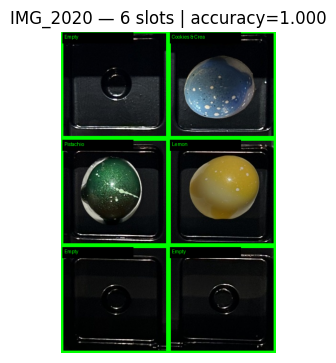

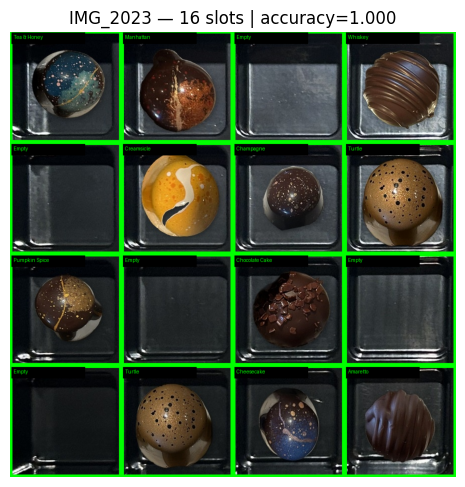

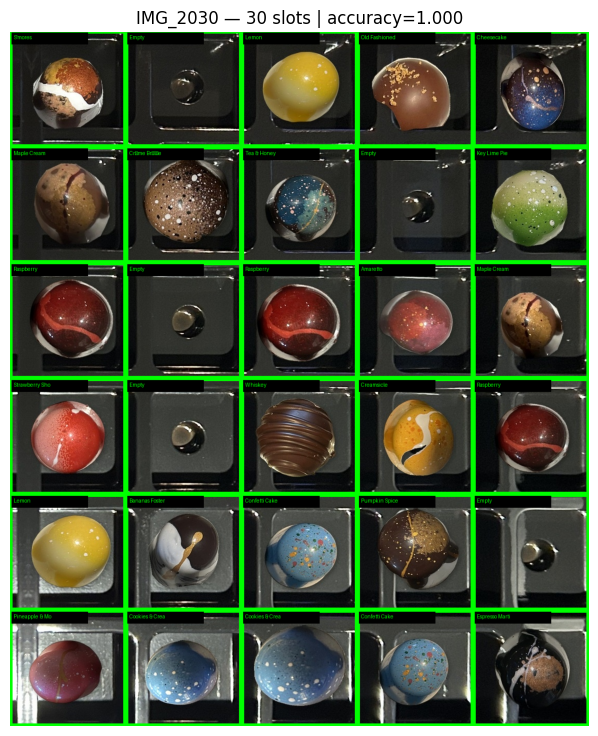

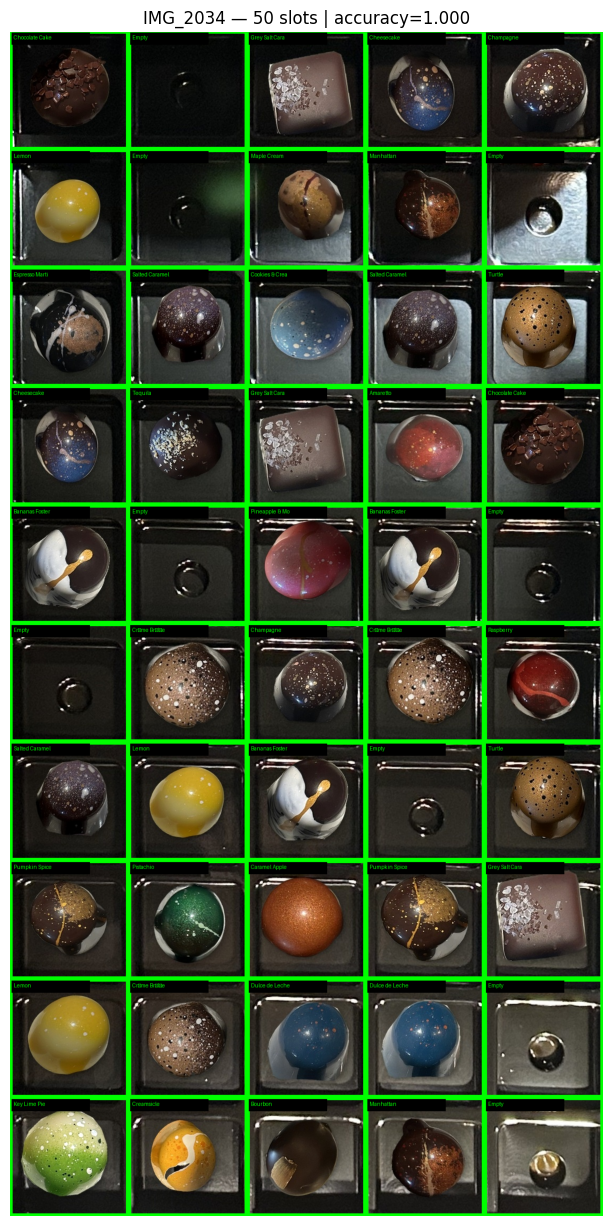

Saved visualizations: /homes/mxqasim/Chocolathon/data/experiments/real_box_inference_v1/synthetic_integration/outputs/visualizations


In [7]:
# Cell 4 — Display box grids with prediction overlays

import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

visualization_dir = OUTPUT_DIR / "visualizations"
visualization_dir.mkdir(parents=True, exist_ok=True)

for box_id, box_rows in slot_predictions.groupby("test_box_id"):
    box_path = BOX_IMAGE_DIR / f"{box_id}_synthetic_box.jpg"
    image = Image.open(box_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    for row in box_rows.itertuples():
        left, top = (row.column - 1) * 224, (row.row - 1) * 224
        right, bottom = left + 223, top + 223
        color = (0, 255, 0) if row.correct and row.decision == "automatic" else (255, 190, 0)
        short_label = "Empty" if row.predicted_flavor_id == "empty" else row.predicted_flavor_name[:14]

        draw.rectangle([left, top, right, bottom], outline=color, width=5)
        draw.rectangle([left + 3, top + 3, left + 150, top + 25], fill=(0, 0, 0))
        draw.text((left + 7, top + 6), short_label, fill=color)

    output_path = visualization_dir / f"{box_id}_predictions.jpg"
    image.save(output_path, quality=95)

    plt.figure(figsize=(min(18, image.width / 180), min(18, image.height / 180)))
    plt.imshow(image)
    plt.title(f"{box_id} — {len(box_rows)} slots | accuracy={box_rows['correct'].mean():.3f}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Saved visualizations:", visualization_dir)

In [8]:
# Cell 5 — Define reusable offline inference for future real-box slot crops

def predict_slot_paths(image_paths, sample_ids=None, batch_size=32):
    image_paths = [Path(path) for path in image_paths]
    sample_ids = sample_ids or [path.stem for path in image_paths]
    prediction_rows = []

    with torch.inference_mode():
        for start in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[start:start + batch_size]
            batch_ids = sample_ids[start:start + batch_size]
            tensors = []

            for path in batch_paths:
                with Image.open(path) as image:
                    tensors.append(transform(image.convert("RGB")))

            embeddings = F.normalize(model(torch.stack(tensors)), dim=1).numpy()
            scores = embeddings @ class_prototypes.T
            rankings = np.argsort(-scores, axis=1)

            for index, (path, sample_id) in enumerate(zip(batch_paths, batch_ids)):
                ranking = rankings[index]
                predicted_id = class_ids[ranking[0]]
                margin = float(scores[index, ranking[0]] - scores[index, ranking[1]])

                prediction_rows.append({
                    "sample_id": sample_id,
                    "image_path": str(path),
                    "predicted_flavor_id": predicted_id,
                    "predicted_flavor_name": class_name_lookup[predicted_id],
                    "top1_similarity": float(scores[index, ranking[0]]),
                    "similarity_margin": margin,
                    "top2_flavor_id": class_ids[ranking[1]],
                    "top3_flavor_id": class_ids[ranking[2]],
                    "decision": "automatic" if margin >= threshold else "review",
                })

    return pd.DataFrame(prediction_rows)

function_test = predict_slot_paths(
    integration_manifest["image_path"].tolist(),
    integration_manifest["sample_id"].astype(str).tolist(),
)

function_test["true_flavor_id"] = integration_manifest["true_flavor_id"].to_numpy()
function_test["correct"] = function_test["predicted_flavor_id"] == function_test["true_flavor_id"]

print("Function test samples:", len(function_test))
print("Correct:", int(function_test["correct"].sum()))
print("Accuracy:", function_test["correct"].mean())
print("Review decisions:", function_test["decision"].eq("review").sum())

assert len(function_test) == 102
assert function_test["correct"].all()

print("PASS: reusable offline slot-inference function is ready")

Function test samples: 102
Correct: 102
Accuracy: 1.0
Review decisions: 0
PASS: reusable offline slot-inference function is ready


In [9]:
# Cell 6 — Create a cryptographic pre-holdout freeze record

from datetime import datetime, timezone
import hashlib
import json

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

frozen_artifacts = {
    "backbone": DEPLOYMENT_DIR / "efficientnet_b0_feature_extractor.pt",
    "prototypes": DEPLOYMENT_DIR / "slot_class_prototypes.npz",
    "class_catalog": DEPLOYMENT_DIR / "class_catalog.csv",
    "deployment_config": DEPLOYMENT_DIR / "deployment_config.json",
    "synthetic_manifest": SYNTHETIC_MANIFEST,
    "integration_predictions": PREDICTION_FILE,
    "integration_counts": COUNT_FILE,
}

freeze_record = {
    "freeze_name": "chocolathon_pre_real_holdout_v1",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "model": "EfficientNet-B0 frozen embeddings with cosine class prototypes",
    "classes": 34,
    "confidence_threshold": threshold,
    "synthetic_validation_top1": 0.998688,
    "synthetic_integration_slots": 102,
    "synthetic_integration_accuracy": 1.0,
    "synthetic_count_absolute_error": 0,
    "real_filled_box_used": False,
    "real_holdout_status": "reserved",
    "artifacts": {
        name: {
            "path": str(path),
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for name, path in frozen_artifacts.items()
    },
}

FREEZE_FILE = INTEGRATION_DIR.parent / "pre_real_holdout_freeze.json"
with open(FREEZE_FILE, "w", encoding="utf-8") as file:
    json.dump(freeze_record, file, indent=2)

print("Freeze record:", FREEZE_FILE)
print("Artifacts frozen:", len(freeze_record["artifacts"]))
print("Real holdout used:", freeze_record["real_filled_box_used"])
print("Real holdout status:", freeze_record["real_holdout_status"])
print()
for name, information in freeze_record["artifacts"].items():
    print(f"{name}: {information['sha256'][:16]}...")

print("\nPASS: system frozen before real filled-box evaluation")

Freeze record: /homes/mxqasim/Chocolathon/data/experiments/real_box_inference_v1/pre_real_holdout_freeze.json
Artifacts frozen: 7
Real holdout used: False
Real holdout status: reserved

backbone: 36d2fa7fff0ed033...
prototypes: d21cffc167c0e665...
class_catalog: 4ea28861dc90e998...
deployment_config: e05abefc8b5af5f8...
synthetic_manifest: f0cc90b60cf655c8...
integration_predictions: 7750e1e60e8c874a...
integration_counts: a70894faaf8b3b85...

PASS: system frozen before real filled-box evaluation


SyntaxError: invalid syntax (1005214991.py, line 1)